Differential interferometry figure
======

In [1]:
import sys
from pathlib import Path

# Add repo root to path so utilities can be imported
repo_root = (
    str(Path(__file__).resolve().parent.parent) if "__file__" in dir() else str(Path.cwd().parent)
)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utilities import get_labbook_dataset_path
from utilities.adevtools import oadev
from utilities.datasets.paths import get_data_dir
from utilities.plots import with_default_styles

%load_ext autoreload
%autoreload 2

# Explicitly define ADev taus

In [2]:
taus_probe = (
    np.array(
        [
            904.09405129,
            1808.18810258,
            3616.37620515,
            7232.75241031,
            14465.50482061,
            28931.00964123,
            57862.01928246,
        ]
    )
    * 0.9
)

# Load monte carlo simulation results

In [3]:
filename_mc = get_labbook_dataset_path("2026-01-20-DAI-Analysis") / "montecarlo_adev_results.csv"
data_mc = pd.read_csv(filename_mc, comment="#")
data_mc

,MC,tau,adev,err_lo,err_hi,n_pairs
0,1,900.99,0.003049,0.000162,0.000192,193.0
1,1,1801.98,0.002344,0.000147,0.000182,191.0
2,1,3603.96,0.001507,0.000123,0.000162,187.0
3,1,7207.92,0.001085,0.000116,0.000170,179.0
4,1,14415.84,0.000762,0.000108,0.000188,163.0
...,...,...,...,...,...,...
35694,5100,3603.96,0.001552,0.000128,0.000170,181.0
35695,5100,7207.92,0.001010,0.000109,0.000162,173.0
35696,5100,14415.84,0.000666,0.000095,0.000168,157.0
35697,5100,28831.68,0.000443,0.000085,0.000201,125.0


In [4]:
filename_stddevs = get_data_dir() / "intermediate_data" / "montecarlo_std_devs.csv"

std_devs = pd.read_csv(filename_stddevs, comment="#")
std_devs

,MC,std_dev_rad
0,1,0.003104
1,2,0.003343
2,3,0.003725
3,4,0.003317
4,5,0.003365
...,...,...
5095,5096,0.003305
5096,5097,0.003569
5097,5098,0.003248
5098,5099,0.003288


In [5]:
montecarlo_adevs_taus = data_mc["tau"].unique()
montecarlo_adevs_taus.sort()
montecarlo_adevs_taus

array([  900.99,  1801.98,  3603.96,  7207.92, 14415.84, 28831.68,
       57663.36])

In [6]:
# Build a dataframe that has tau as the columns and each row is one MC run (identified by the "MC" column in data_mc)
# Pivot the dataframe to have tau_s as columns and MC runs as rows
adevs = data_mc.pivot(index="MC", columns="tau", values="adev")
adevs

tau,900.99,1801.98,3603.96,7207.92,14415.84,28831.68,57663.36
MC,,,,,,,
1,0.003049,0.002344,0.001507,0.001085,0.000762,0.000385,0.000258
2,0.003362,0.002143,0.001724,0.001247,0.001156,0.000941,0.000473
3,0.003843,0.002522,0.001705,0.001162,0.000934,0.000851,0.000485
4,0.003447,0.002202,0.001746,0.001263,0.000565,0.000346,0.000266
5,0.003394,0.002279,0.001886,0.001108,0.000834,0.000627,0.000265
...,...,...,...,...,...,...,...
5096,0.003351,0.002323,0.001644,0.001173,0.000926,0.000514,0.000227
5097,0.003665,0.002385,0.001615,0.001182,0.001002,0.000732,0.000703
5098,0.003136,0.002255,0.001714,0.001483,0.000916,0.000499,0.000256


In [7]:
montecarlo_adevs_mean = np.mean(adevs, axis=0)

# Get 68% and 95% confidence intervals
montecarlo_adevs_68ci_lower = np.nanpercentile(adevs, 16, axis=0)
montecarlo_adevs_68ci_upper = np.nanpercentile(adevs, 84, axis=0)
montecarlo_adevs_95ci_lower = np.nanpercentile(adevs, 2.5, axis=0)
montecarlo_adevs_95ci_upper = np.nanpercentile(adevs, 97.5, axis=0)

# Import the raw data

In [8]:
# Copy / paste from processing notebook:>
data_description = """
{
  "0": {
    "excitation": "excitation_fraction_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_0.csv",
    "ellipse": "ellipse_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_0.csv",
    "excitation_corrected": "excitation_fraction_corrected_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_0.csv",
    "excitation_corrected_with_phi": "excitation_fraction_corrected_with_phi_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_0.csv"
  },
  "2": {
    "excitation": "excitation_fraction_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_2.csv",
    "ellipse": "ellipse_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_2.csv",
    "excitation_corrected": "excitation_fraction_corrected_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_2.csv",
    "excitation_corrected_with_phi": "excitation_fraction_corrected_with_phi_hln-lnl-repeat_63132_63134_63133_63135_63150_63149_63148_63151_63164_63163_63162_63331_63333_63332_2.csv"
  }
}
"""

In [9]:
import json

data_description_dict = json.loads(data_description)

key_nonrandomised = "0"
key_randomised = "2"

file_non_randomised = (
    get_data_dir()
    / "intermediate_data"
    / data_description_dict[key_nonrandomised]["excitation_corrected_with_phi"]
)
data_nonrandomised = pd.read_csv(file_non_randomised, comment="#")
data_nonrandomised

,timestamp,phi,excitation_fraction_forward,excitation_fraction_backward,fluorescence_counts_forward,fluorescence_counts_backward,stark_shifter_setpoint
0,1.766173e+09,4.950388,0.084711,0.080917,1.260023e+06,772510.031569,3.503289
1,1.766173e+09,5.077321,0.089187,0.104078,1.281105e+06,792506.432377,3.502693
2,1.766173e+09,0.253866,0.930808,0.906428,1.321364e+06,775951.002717,3.499688
3,1.766173e+09,3.871458,0.708275,0.646063,1.357612e+06,778273.151082,3.499089
4,1.766173e+09,0.000000,0.891305,0.884731,1.329988e+06,783505.850826,3.498494
...,...,...,...,...,...,...,...
28304,1.766396e+09,2.475194,0.412285,0.465157,1.133948e+06,619595.190630,3.500000
28305,1.766396e+09,5.394654,0.222400,0.272205,1.115267e+06,617785.404535,3.500000
28306,1.766396e+09,4.886922,0.098449,0.086866,1.073022e+06,587227.153239,3.500000
28307,1.766396e+09,5.204254,0.122378,0.162391,1.130711e+06,628799.548106,3.500000


In [10]:
file_randomised = (
    get_data_dir()
    / "intermediate_data"
    / data_description_dict[key_randomised]["excitation_corrected_with_phi"]
)
data_randomised = pd.read_csv(file_randomised, comment="#")
data_randomised

,timestamp,phi,excitation_fraction_forward,excitation_fraction_backward,fluorescence_counts_forward,fluorescence_counts_backward,stark_shifter_setpoint
0,1.766173e+09,5.140788,0.088668,0.103931,1.336854e+06,794326.356156,3.502090
1,1.766173e+09,4.633056,0.671901,0.694076,1.302791e+06,754439.189005,3.501489
2,1.766173e+09,5.331188,0.821987,0.836824,1.343198e+06,748939.886209,3.500887
3,1.766173e+09,4.315723,0.825543,0.851619,1.305981e+06,762421.091084,3.500288
4,1.766173e+09,1.903996,0.904227,0.899094,1.353810e+06,774719.653824,3.497889
...,...,...,...,...,...,...,...
28309,1.766396e+09,1.523196,0.806768,0.770164,1.075390e+06,644462.630456,3.500000
28310,1.766396e+09,0.698132,0.833842,0.788859,1.097883e+06,626945.359207,3.500000
28311,1.766396e+09,3.998391,0.867011,0.854150,1.095143e+06,599840.319385,3.500000
28312,1.766396e+09,5.838920,0.878689,0.913093,1.069546e+06,594969.352942,3.500000


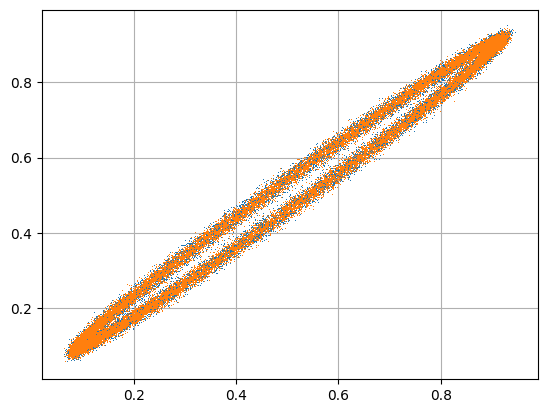

In [11]:
plt.plot(
    data_randomised["excitation_fraction_forward"],
    data_randomised["excitation_fraction_backward"],
    ",",
)
plt.plot(
    data_nonrandomised["excitation_fraction_forward"],
    data_nonrandomised["excitation_fraction_backward"],
    ",",
)

# Load processed delta phi

In [12]:
# Load residual timeseries data

delta_phi_hln = pd.read_csv(
    get_labbook_dataset_path("2026-01-20-DAI-Analysis") / "residual_timeseries_HN.csv"
).set_index("bin_t_centre_s")
delta_phi_lln = pd.read_csv(
    get_labbook_dataset_path("2026-01-20-DAI-Analysis") / "residual_timeseries_LN.csv"
).set_index("bin_t_centre_s")

delta_phi_hln

,bin_index,bin_t_start_s,bin_t_end_s,bin_t_hours_from_start,bin_duration_s,bin_n_shots,bin_delta_raw_rad,bin_delta_used_rad,bin_err_rad,delta_model_rad,residual_wrapped_rad,residual_for_allan_rad,bin_flags,transform_info
bin_t_centre_s,,,,,,,,,,,,,,
438.805009,0,0.000000,882.601200,0.000000,882.601200,141,-0.098161,-0.098161,0.003288,0.0,-0.001863,-0.001863,0,0
1355.737334,1,885.765194,1861.237567,0.254703,975.472372,141,-0.098406,-0.098406,0.003063,0.0,-0.002108,-0.002108,0,0
2319.332168,2,1867.580029,2734.896271,0.522369,867.316242,141,-0.101389,-0.101389,0.003362,0.0,-0.005090,-0.005090,0,0
3195.356015,3,2741.272374,3684.339068,0.765709,943.066694,141,-0.098414,-0.098414,0.003063,0.0,-0.002115,-0.002115,0,0
4139.249178,4,3690.761699,4571.620704,1.027901,880.859004,141,-0.095865,-0.095865,0.003253,0.0,0.000434,0.000434,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218009.049650,195,217561.197602,218438.927837,60.436179,877.730235,141,-0.104010,-0.104010,0.003482,0.0,-0.007711,-0.007711,0,0
218888.570671,196,218442.154494,219329.072713,60.680490,886.918220,141,-0.107364,-0.107364,0.003687,0.0,-0.011065,-0.011065,0,0
219832.694733,197,219332.268167,220270.610750,60.942747,938.342582,141,-0.099587,-0.099587,0.003641,0.0,-0.003289,-0.003289,0,0


In [13]:
delta_phi_lln

,bin_index,bin_t_start_s,bin_t_end_s,bin_t_hours_from_start,bin_duration_s,bin_n_shots,bin_delta_raw_rad,bin_delta_used_rad,bin_err_rad,delta_model_rad,residual_wrapped_rad,residual_for_allan_rad,bin_flags,transform_info
bin_t_centre_s,,,,,,,,,,,,,,
450.332706,0,0.000000,908.082385,0.000000,908.082385,141,-0.099674,-0.099674,0.003340,0.0,-0.000384,-0.000384,0,0
1360.544856,1,911.261600,1832.529327,0.252837,921.267727,141,-0.094825,-0.094825,0.003362,0.0,0.004466,0.004466,0,0
2265.442546,2,1835.709529,2744.479714,0.504197,908.770186,141,-0.101796,-0.101796,0.003260,0.0,-0.002505,-0.002505,0,0
3192.465774,3,2754.016350,3594.971232,0.761704,840.954882,141,-0.098230,-0.098230,0.003392,0.0,0.001061,0.001061,0,0
4050.748457,4,3601.345739,4523.661667,1.000115,922.315928,141,-0.100249,-0.100249,0.003315,0.0,-0.000958,-0.000958,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218056.751097,195,217593.068132,218528.423311,60.446227,935.355178,141,-0.107516,-0.107516,0.003682,0.0,-0.008225,-0.008225,0,0
218974.647821,196,218531.618409,219412.003151,60.701199,880.384742,141,-0.097619,-0.097619,0.003656,0.0,0.001672,0.001672,0,0
219829.465494,197,219418.394080,220286.538302,60.938648,868.144222,141,-0.102311,-0.102311,0.003755,0.0,-0.003020,-0.003020,0,0


In [14]:
# Apply filters
k_glitch_hln = delta_phi_hln["bin_flags"] != 0
k_glitch_lln = delta_phi_lln["bin_flags"] != 0

# Use the "bin_delta_used_rad" column's absolute value
timeseries_for_adev_hln = delta_phi_hln.loc[~k_glitch_hln, "bin_delta_used_rad"].abs()
timeseries_for_adev_lln = delta_phi_lln.loc[~k_glitch_lln, "bin_delta_used_rad"].abs()

## Plot both ADevs together


In [15]:
# Calculate ADevs for both
sample_rate_lln = 1 / (np.median(np.diff(timeseries_for_adev_lln.index)))
sample_rate_hln = 1 / (np.median(np.diff(timeseries_for_adev_hln.index)))

taus_hln, ad_hln, ade_p_hln, ade_n_hln, _ = oadev(
    timeseries_for_adev_hln.to_numpy(), rate=sample_rate_hln, taus=taus_probe
)
taus_lln, ad_lln, ade_p_lln, ade_n_lln, _ = oadev(
    timeseries_for_adev_lln.to_numpy(), rate=sample_rate_lln, taus=taus_probe
)

In [16]:
# Compare the first ADevs point with the standard deviations

print("HLN:")
print(
    f"ADev: {1e3 * ad_hln[0]:.6f} mrad, 1-sigma: {1e3 * np.std(timeseries_for_adev_hln.to_numpy()):.6f} mrad"
)
print("LLN:")
print(
    f"ADev: {1e3 * ad_lln[0]:.6f} mrad, 1-sigma: {1e3 * np.std(timeseries_for_adev_lln.to_numpy()):.6f} mrad"
)

HLN:
ADev: 3.405002 mrad, 1-sigma: 3.573283 mrad
LLN:
ADev: 3.484142 mrad, 1-sigma: 3.447760 mrad


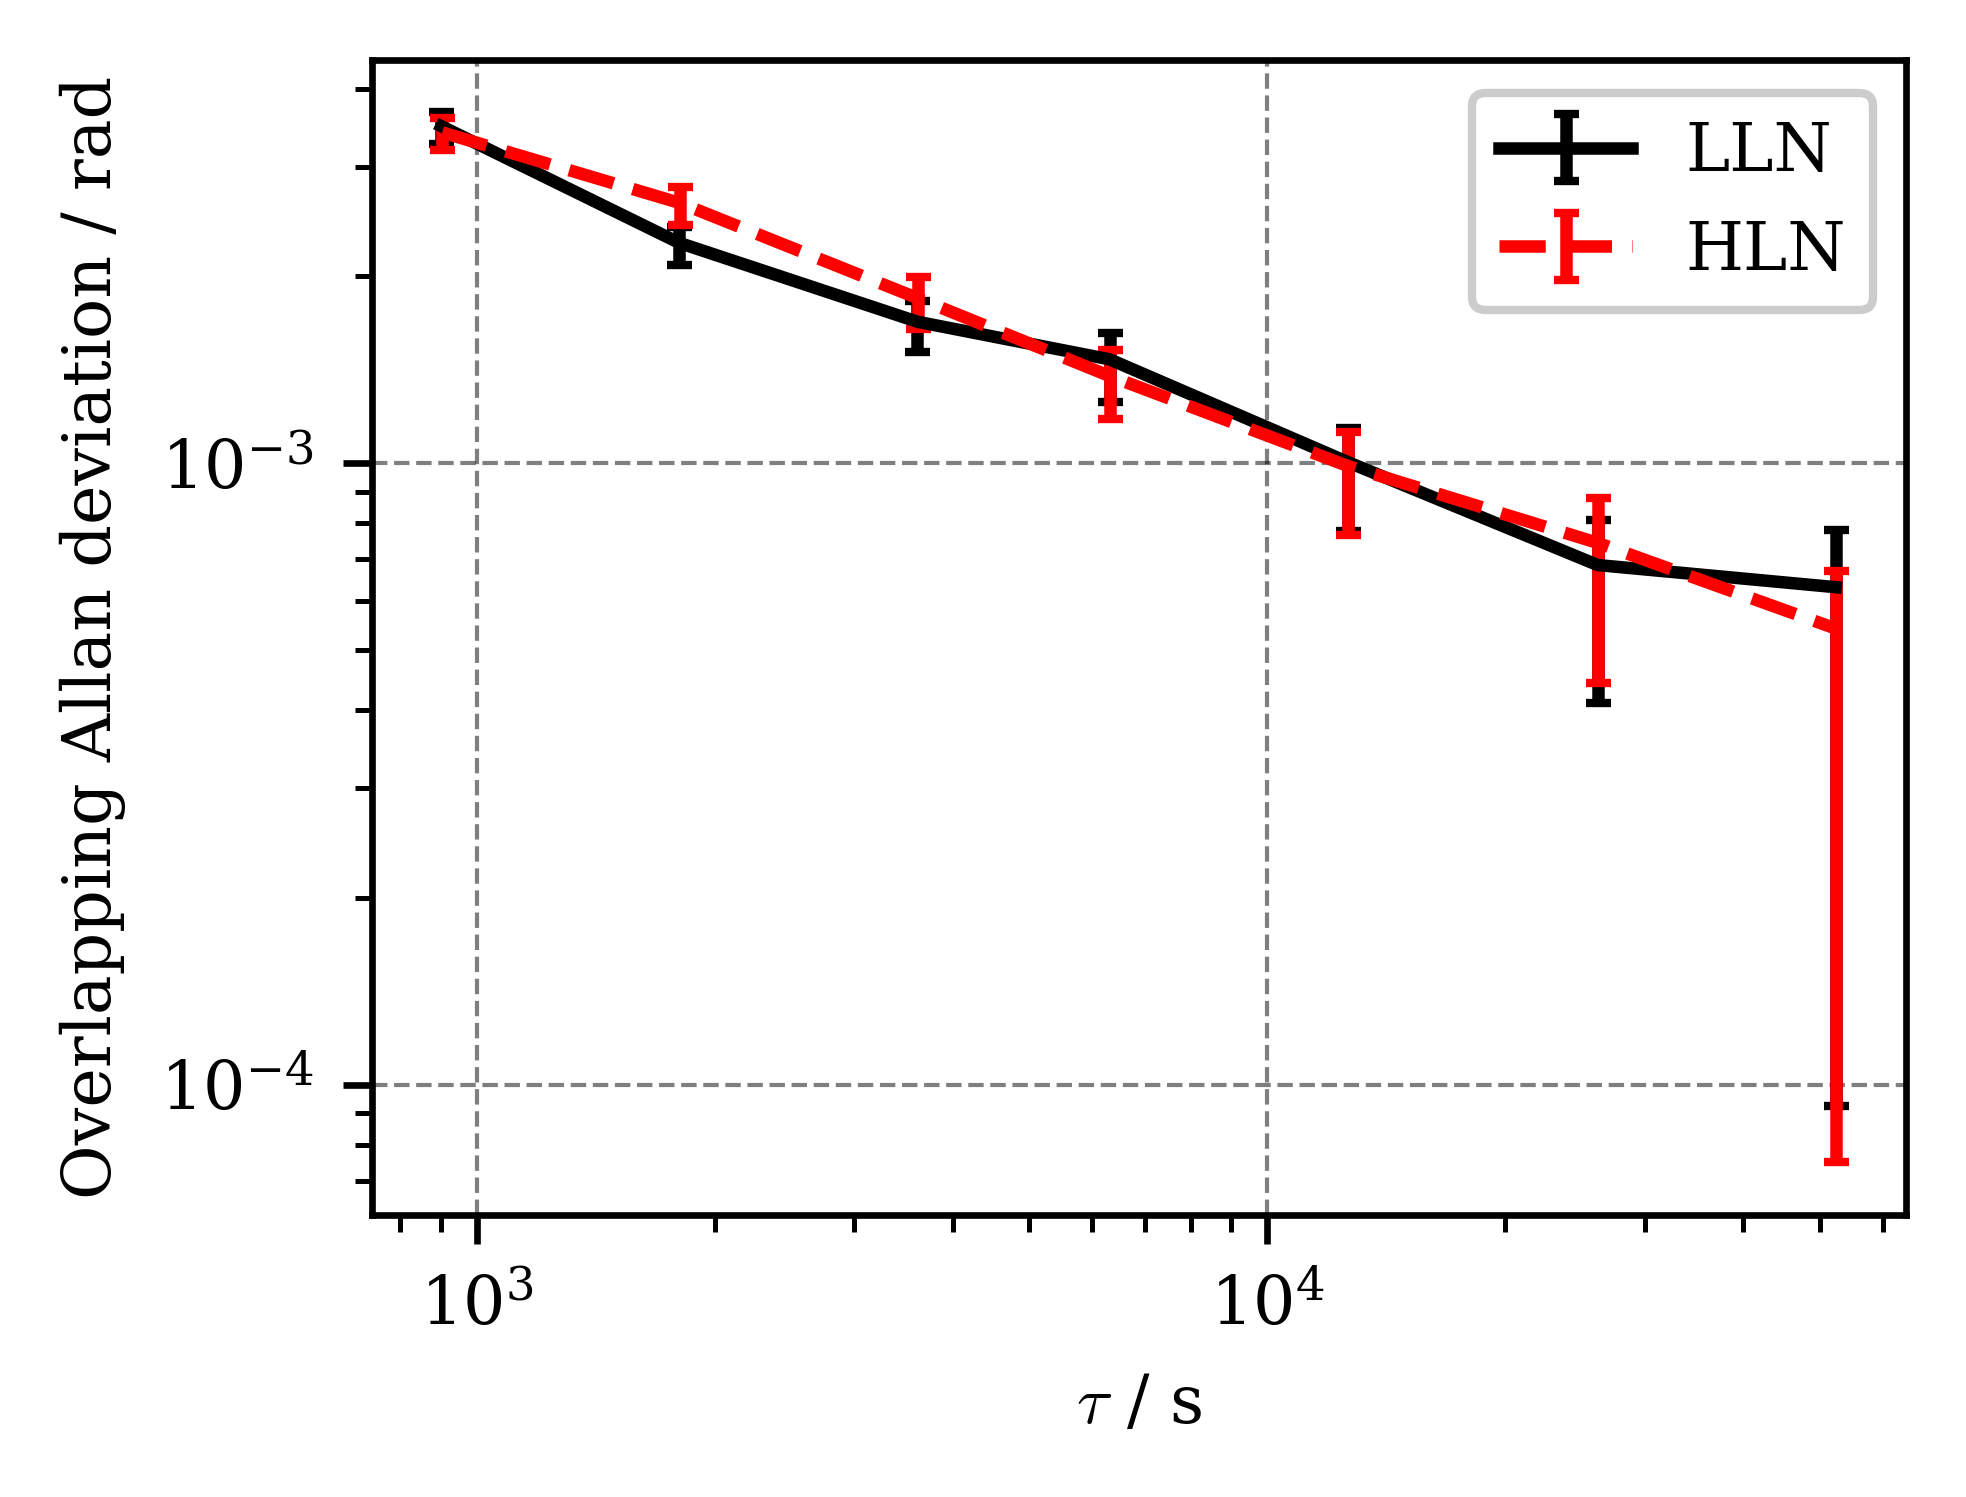

In [17]:
with with_default_styles():
    plt.figure()
    plt.errorbar(taus_lln, ad_lln, yerr=[ade_n_lln, ade_p_lln], label="LLN")
    plt.errorbar(taus_hln, ad_hln, yerr=[ade_n_hln, ade_p_hln], label="HLN")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()

    plt.xlabel("$\\tau$ / s")
    plt.ylabel("Overlapping Allan deviation / rad")

# Theoretical SQL calculations

In [18]:
# Copied from paper manually
# % Theoretical SQL, entered manually, per shot

import uncertainties

theoreticalSQLSingleShot = uncertainties.ufloat(43.5, 1.6) * 1e-3  # in rad

# Import analysis of noise levels

In [19]:
dataNumShots = data_nonrandomised.shape[0] + data_randomised.shape[0]
shotsPerBin = np.floor(dataNumShots / (delta_phi_lln.shape[0] + delta_phi_hln.shape[0]))

In [20]:
filename_randomised = get_data_dir() / "intermediate_data" / "sigma_delta_phi_randomised.npy"
filename_nonrandomised = get_data_dir() / "intermediate_data" / "sigma_delta_phi_nonrandomised.npy"
filename_sql = get_data_dir() / "intermediate_data" / "montecarlo_std_devs.csv"

sigma_delta_phi_randomised = np.load(filename_randomised)
sigma_delta_phi_nonrandomised = np.load(filename_nonrandomised)

mean_randomised_sigma = np.mean(sigma_delta_phi_randomised)
mean_nonrandomised_sigma = np.mean(sigma_delta_phi_nonrandomised)
errors_randomised_sigma = np.abs(
    np.percentile(sigma_delta_phi_randomised, [16, 84]) - mean_randomised_sigma
)
errors_nonrandomised_sigma = np.abs(
    np.percentile(sigma_delta_phi_nonrandomised, [16, 84]) - mean_nonrandomised_sigma
)

std_devs = pd.read_csv(filename_sql, comment="#").set_index("MC").squeeze()
std_devs

MC
1       0.003104
2       0.003343
3       0.003725
4       0.003317
5       0.003365
          ...   
5096    0.003305
5097    0.003569
5098    0.003248
5099    0.003288
5100    0.003445
Name: std_dev_rad, Length: 5100, dtype: float64

In [21]:
std_dev_1s = np.abs(np.nanpercentile(std_devs, [16, 84]) - std_devs.mean())
std_dev_1s

array([0.00018085, 0.00018208])

# Produce paper outputs

In [23]:
# Scale the theoretical SQL to the number of shots in each dataset
num_shots_randomised = data_randomised.shape[0]
num_shots_nonrandomised = data_nonrandomised.shape[0]

# Calculate the scaled theoretical SQLs over the whole datasets
theoreticalSQL_randomised = theoreticalSQLSingleShot / np.sqrt(num_shots_randomised)
theoreticalSQL_nonrandomised = theoreticalSQLSingleShot / np.sqrt(num_shots_nonrandomised)
theoreticalSQL_mean = theoreticalSQLSingleShot / np.sqrt(dataNumShots / 2)
theoreticalSQL_mean_per_block = theoreticalSQLSingleShot / np.sqrt(shotsPerBin)

# Scale the mean_randomised_sigma and mean_nonrandomised_sigma by the
# number of *blocks* since they refer to the std.dev. of blocks of shots
mean_randomised_sigma_whole_dataset = uncertainties.ufloat(
    mean_randomised_sigma / np.sqrt(num_shots_randomised / shotsPerBin),
    errors_randomised_sigma[0] / np.sqrt(num_shots_randomised / shotsPerBin),
)
mean_nonrandomised_sigma_whole_dataset = uncertainties.ufloat(
    mean_nonrandomised_sigma / np.sqrt(num_shots_nonrandomised / shotsPerBin),
    errors_nonrandomised_sigma[0] / np.sqrt(num_shots_nonrandomised / shotsPerBin),
)

# Calculate the difference between our observed noise and theoretical minimum
highLaserNoiseSigmaMinusSQL = mean_randomised_sigma_whole_dataset - theoreticalSQL_randomised
lowLaserNoiseSigmaMinusSQL = mean_nonrandomised_sigma_whole_dataset - theoreticalSQL_nonrandomised
highLaserNoiseSigmaMinusLowLaserNoiseSigma = (
    mean_randomised_sigma_whole_dataset - mean_nonrandomised_sigma_whole_dataset
)

dataDurationHours = (
    data_nonrandomised["timestamp"].max() - data_nonrandomised["timestamp"].min()
) / 3600.0

numMCSims = adevs.shape[0]


print(
    f"""
% Output from labbook code analysis
\\newcommand\\lowLaserNoiseSigmaOneBlock{{\\qty{{{1e3 * mean_nonrandomised_sigma:.2f}({1e5 * np.mean(errors_nonrandomised_sigma):.0f})}}{{\\milli\\radian}}}}
\\newcommand\\highLaserNoiseSigmaOneBlock{{\\qty{{{1e3 * mean_randomised_sigma:.2f}({1e5 * np.mean(errors_randomised_sigma):.0f})}}{{\\milli\\radian}}}}
\\newcommand\\lowLaserNoiseSigmaWholeDataset{{\\qty{{{1e6 * mean_nonrandomised_sigma_whole_dataset.n:.0f}({1e6 * mean_nonrandomised_sigma_whole_dataset.s:.0f})}}{{\\micro\\radian}}}}
\\newcommand\\highLaserNoiseSigmaWholeDataset{{\\qty{{{1e6 * mean_randomised_sigma_whole_dataset.n:.0f}({1e6 * mean_randomised_sigma_whole_dataset.s:.0f})}}{{\\micro\\radian}}}}
\\newcommand\\highLaserNoiseSigmaMinusSQL{{\\qty{{{1e6 * highLaserNoiseSigmaMinusSQL.n:.0f}({1e6 * highLaserNoiseSigmaMinusSQL.s:.0f})}}{{\\micro\\radian}}}}
\\newcommand\\lowLaserNoiseSigmaMinusSQL{{\\qty{{{1e6 * lowLaserNoiseSigmaMinusSQL.n:.0f}({1e6 * lowLaserNoiseSigmaMinusSQL.s:.0f})}}{{\\micro\\radian}}}}
\\newcommand\\differenceSigmaWholeDataset{{\\qty{{{1e6 * highLaserNoiseSigmaMinusLowLaserNoiseSigma.n:.0f}({1e6 * highLaserNoiseSigmaMinusLowLaserNoiseSigma.s:.0f})}}{{\\micro\\radian}}}}
\\newcommand\\dataNumShots{{\\num{{{dataNumShots}}}}}
\\newcommand\\dataNumShotsSingle{{\\num{{{dataNumShots / 2:.0f}}}}}
\\newcommand\\dataDuration{{\\qty{{{dataDurationHours:.1f}}}{{h}}}}
\\newcommand\\numMCSims{{\\num{{{numMCSims}}}}}
\\newcommand\\shotsPerBin{{\\num{{{shotsPerBin:.0f}}}}}
""".strip()
)

% Output from labbook code analysis aece16e-dirty
\newcommand\lowLaserNoiseSigmaOneBlock{\qty{3.69(19)}{\milli\radian}}
\newcommand\highLaserNoiseSigmaOneBlock{\qty{3.89(20)}{\milli\radian}}
\newcommand\lowLaserNoiseSigmaWholeDataset{\qty{260(13)}{\micro\radian}}
\newcommand\highLaserNoiseSigmaWholeDataset{\qty{275(14)}{\micro\radian}}
\newcommand\highLaserNoiseSigmaMinusSQL{\qty{16(17)}{\micro\radian}}
\newcommand\lowLaserNoiseSigmaMinusSQL{\qty{2(16)}{\micro\radian}}
\newcommand\differenceSigmaWholeDataset{\qty{14(19)}{\micro\radian}}
\newcommand\dataNumShots{\num{56623}}
\newcommand\dataNumShotsSingle{\num{28312}}
\newcommand\dataDuration{\qty{61.9}{h}}
\newcommand\numMCSims{\num{5100}}
\newcommand\shotsPerBin{\num{141}}


/tmp/ipykernel_1513026/2335815157.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


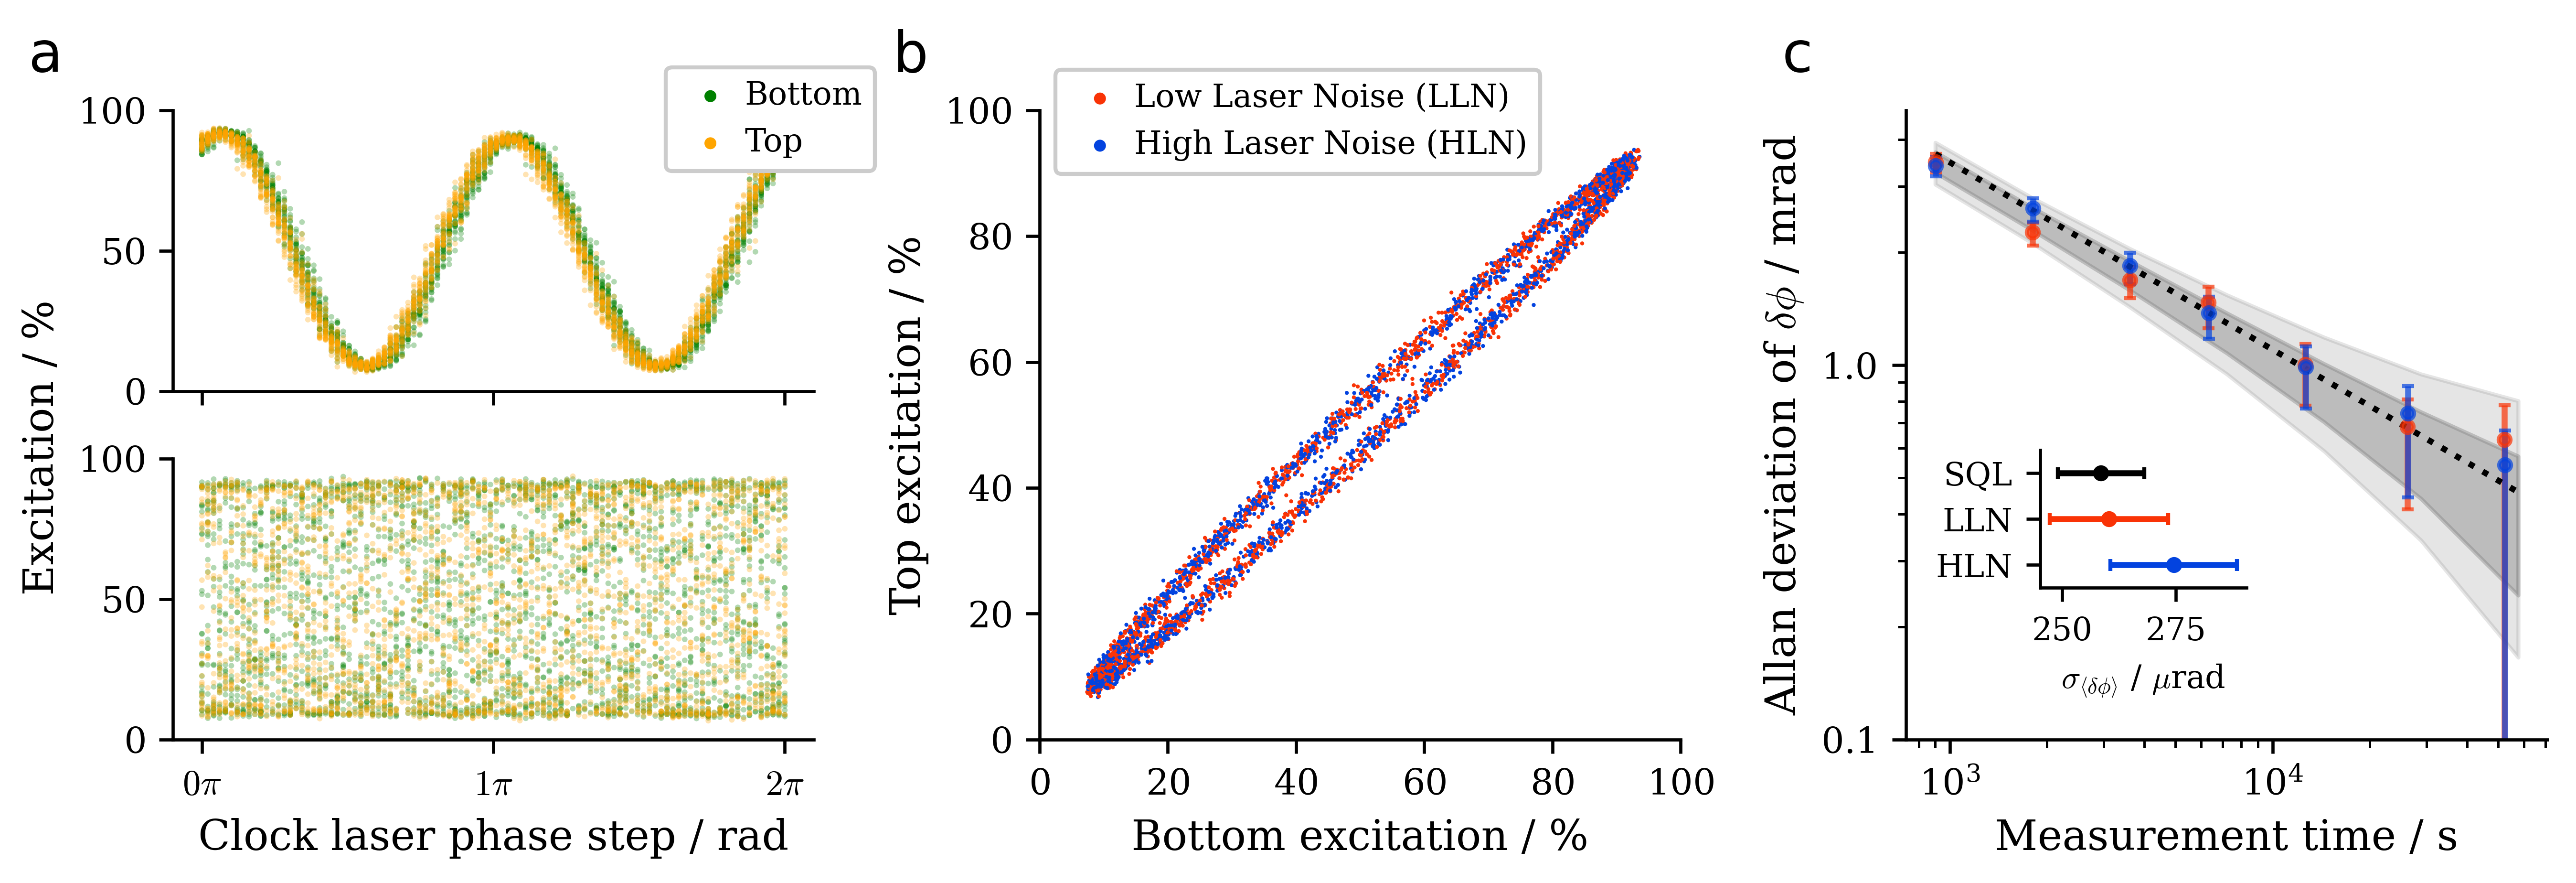

In [24]:
import matplotlib.gridspec as gridspec

with with_default_styles():
    fig = plt.figure(figsize=(9, 3))
    gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

    ax_fringes_nonrandomised = fig.add_subplot(gs[0, 0])
    ax_fringes_randomised = fig.add_subplot(gs[1, 0])
    ax_ellipse = fig.add_subplot(gs[:, 1])
    ax_adev = fig.add_subplot(gs[:, 2])

    axis_label_fontize = 10.5

    handletextpad = 0.08  # distance between points and labels in legends
    color_random = "#0343DF"
    color_nonrandom = "#F93306"
    color_sql = "#000000"

    # First column - Fringe plots
    markersize_ex = 8
    markersize_ex_legend = 6
    alpha_ex = 0.3
    markerscale_legend = markersize_ex_legend / np.sqrt(markersize_ex)
    color_bkwd = "orange"
    color_fwd = "g"
    truncation_fringes = 3000

    # Extract real fringe data
    phi_nonrandomised = data_nonrandomised["phi"][:truncation_fringes]
    ex_fwd_nonrandomised = data_nonrandomised["excitation_fraction_forward"][:truncation_fringes]
    ex_bkwd_nonrandomised = data_nonrandomised["excitation_fraction_backward"][:truncation_fringes]

    phi_randomised = data_randomised["phi"][:truncation_fringes]
    ex_fwd_randomised = data_randomised["excitation_fraction_forward"][:truncation_fringes]
    ex_bkwd_randomised = data_randomised["excitation_fraction_backward"][:truncation_fringes]

    ax_fringes_nonrandomised.scatter(
        phi_nonrandomised,
        100 * ex_fwd_nonrandomised,
        marker=".",
        label="Bottom",
        s=markersize_ex,
        linestyle="None",
        alpha=alpha_ex,
        color=color_fwd,
        edgecolors="none",
    )
    ax_fringes_nonrandomised.scatter(
        phi_nonrandomised,
        100 * ex_bkwd_nonrandomised,
        marker=".",
        label="Top",
        s=markersize_ex,
        linestyle="None",
        alpha=alpha_ex,
        color=color_bkwd,
        edgecolors="none",
    )

    ax_fringes_nonrandomised.set_ylabel("Excitation / %", fontsize=axis_label_fontize)
    leg = ax_fringes_nonrandomised.legend(
        markerscale=markerscale_legend,
        loc="upper right",
        handletextpad=handletextpad,
        bbox_to_anchor=(1.12, 1.21),
    )
    for lh in leg.legend_handles:
        lh.set_alpha(1)
    x_ticks = np.linspace(0, 2 * np.pi, 3)
    x_labels = [f"${x / np.pi:.0f}\\pi$" for x in x_ticks]
    ax_fringes_nonrandomised.set_xticks(x_ticks)
    ax_fringes_nonrandomised.set_xticklabels([])
    ax_fringes_nonrandomised.set_ylim([0, 100])
    ax_fringes_nonrandomised.grid(False)
    ax_fringes_nonrandomised.spines[["right", "top"]].set_visible(False)

    ax_fringes_randomised.scatter(
        phi_randomised,
        100 * ex_fwd_randomised,
        marker=".",
        label="Bottom",
        s=markersize_ex,
        linestyle="None",
        alpha=alpha_ex,
        color=color_fwd,
        edgecolors="none",
    )
    ax_fringes_randomised.scatter(
        phi_randomised,
        100 * ex_bkwd_randomised,
        marker=".",
        label="Top",
        s=markersize_ex,
        linestyle="None",
        alpha=alpha_ex,
        color=color_bkwd,
        edgecolors="none",
    )

    ax_fringes_randomised.set_xlabel("Clock laser phase step / rad", fontsize=axis_label_fontize)
    ax_fringes_randomised.set_xticks(x_ticks)
    ax_fringes_randomised.set_xticklabels(x_labels)
    ax_fringes_randomised.set_ylim([0, 100])
    ax_fringes_randomised.grid(False)
    ax_fringes_randomised.spines[["right", "top"]].set_visible(False)

    # Second column - Ellipse plot (data available!)
    markersize_lissajous = 4
    markersize_lissajous_legend = 6
    markerscale_lissajous_legend = markersize_lissajous_legend / np.sqrt(markersize_lissajous)
    alpha_lissajous = 1
    truncation = 2000
    points_per_plotstep = truncation // 10

    bool_legend = True  # To avoid extra legend entries
    # For loop to interleave plotting of points --> not one preferentially on top of other
    for idx in range(0, truncation, points_per_plotstep):
        ax_ellipse.scatter(
            100
            * data_nonrandomised["excitation_fraction_forward"][idx : idx + points_per_plotstep],
            100
            * data_nonrandomised["excitation_fraction_backward"][idx : idx + points_per_plotstep],
            s=markersize_lissajous,
            marker=".",
            label="Low Laser Noise (LLN)" if bool_legend else None,
            alpha=alpha_lissajous,
            color=color_nonrandom,
            edgecolors="none",
        )
        ax_ellipse.scatter(
            100 * data_randomised["excitation_fraction_forward"][idx : idx + points_per_plotstep],
            100 * data_randomised["excitation_fraction_backward"][idx : idx + points_per_plotstep],
            s=markersize_lissajous,
            marker=".",
            label="High Laser Noise (HLN)" if bool_legend else None,
            alpha=alpha_lissajous,
            color=color_random,
            edgecolors="none",
        )
        bool_legend = False

    ax_ellipse.set_xlabel("Bottom excitation / %", fontsize=axis_label_fontize)
    ax_ellipse.set_ylabel("Top excitation / %", fontsize=axis_label_fontize)
    ax_ellipse.grid(False)
    ax_ellipse.legend(
        markerscale=markerscale_lissajous_legend,
        loc="upper left",
        handletextpad=handletextpad,
        bbox_to_anchor=(0.0, 1.09),
    )
    ax_ellipse.set_xlim([0, 100])
    ax_ellipse.set_ylim([0, 100])
    ax_ellipse.spines[["right", "top"]].set_visible(False)

    # Third column - Allan deviation plot
    ax_adev.errorbar(
        taus_lln,
        ad_lln,
        np.array([ade_n_lln, ade_p_lln]),
        label="LLN",
        linestyle="None",
        color=color_nonrandom,
        marker="o",
        alpha=0.7,
        ms=3,
    )
    ax_adev.errorbar(
        taus_hln,
        ad_hln,
        np.array([ade_n_hln, ade_p_hln]),
        label="HLN",
        linestyle="None",
        color=color_random,
        marker="o",
        alpha=0.7,
        ms=3,
    )

    montecarlo_adevs_taus = montecarlo_adevs_mean.index.values

    ax_adev.fill_between(
        montecarlo_adevs_taus,
        montecarlo_adevs_95ci_lower,
        montecarlo_adevs_95ci_upper,
        color="grey",
        alpha=0.2,
        label="SQL Uncertainty",
    )

    ax_adev.fill_between(
        montecarlo_adevs_taus,
        montecarlo_adevs_68ci_lower,
        montecarlo_adevs_68ci_upper,
        color="grey",
        alpha=0.4,
        label="SQL 68% CI",
    )

    # Add 1/sqrt(tau) scaling line at the Cramer-rao bound
    sql_scaling_line = theoreticalSQL_mean_per_block.n * np.sqrt(
        montecarlo_adevs_taus[0] / montecarlo_adevs_taus
    )
    ax_adev.plot(
        montecarlo_adevs_taus,
        sql_scaling_line,
        "k:",
        linewidth=1.5,
        label=r"SQL $1/\sqrt{\tau}$",
    )

    ax_adev.set_xscale("log")
    ax_adev.set_yscale("log")
    # Disable minor tick labels
    ax_adev.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{1e3 * x:.1f}"))
    ax_adev.yaxis.set_minor_formatter(plt.NullFormatter())
    ax_adev.set_ylabel(r"Allan deviation of $\delta\phi$ / mrad", fontsize=axis_label_fontize)
    ax_adev.set_xlabel("Measurement time / s", fontsize=axis_label_fontize)

    ax_adev.set_ylim([100e-6, None])

    ax_adev.grid(False)
    ax_adev.spines[["right", "top"]].set_visible(False)

    for ax in [ax_fringes_nonrandomised, ax_fringes_randomised, ax_ellipse, ax_adev]:
        ax.tick_params(axis="both", which="major", labelsize=9)
        ax.tick_params(axis="both", which="minor", labelsize=9)

    # Error bar inset
    ax_errorbar_inset = plt.axes([0.79, 0.35, 0.08, 0.16])  # lower left

    ax_errorbar_inset.errorbar(
        mean_randomised_sigma_whole_dataset.n,
        [1],
        xerr=mean_randomised_sigma_whole_dataset.s,
        fmt="o",
        color=color_random,
        label="HLN",
        ms=3,
    )
    ax_errorbar_inset.errorbar(
        mean_nonrandomised_sigma_whole_dataset.n,
        [2],
        xerr=mean_nonrandomised_sigma_whole_dataset.s,
        fmt="o",
        color=color_nonrandom,
        label="LLN",
        ms=3,
    )
    ax_errorbar_inset.errorbar(
        theoreticalSQL_mean.n,
        [3],
        xerr=theoreticalSQL_mean.s,
        fmt="o",
        color=color_sql,
        label="SQL",
        ms=3,
    )
    ax_errorbar_inset.set_yticks([1, 2, 3])
    ax_errorbar_inset.set_yticklabels(["HLN", "LLN", "SQL"])
    ax_errorbar_inset.spines[["right", "top"]].set_visible(False)
    ax_errorbar_inset.grid(False)
    ax_errorbar_inset.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{1e6 * x:.0f}"))
    ax_errorbar_inset.set_xlabel(r"$\sigma_{\left<\delta\phi\right>}$ / $\mu$rad")
    ax_errorbar_inset.set_ylim([0.5, 3.5])
    ax_errorbar_inset.patch.set_alpha(0)

    # Rejiggle everything to make it fit
    fig.tight_layout()

    # Shift the y axis label for the non-random plot downwards so that it applies to both
    label = ax_fringes_nonrandomised.yaxis.get_label()
    x, y = label.get_position()
    label.set_position((x, y - 0.7))

    # Put sub-plot labels around
    ypos = 0.95
    label_positions = [
        ("a", 0.01, ypos),
        ("b", 0.345, ypos),
        ("c", 0.69, ypos),
    ]
    for label, x, y in label_positions:
        fig.text(x, y, label, fontsize=14, fontfamily="sans-serif")

In [25]:
fig.savefig("Figure 4.svg")
fig.savefig("Figure 4.png")
fig.savefig("Figure 4.pdf")

In [26]:
from openpyxl import Workbook

wb = Workbook()
wb.remove(wb.active)

# Sheet (a): fringes_nonrandomised
ws = wb.create_sheet("fringes_nonrandomised")
ws.append(["phi_rad", "excitation_forward_pct", "excitation_backward_pct"])
truncation_fringes = 3000
phi_n = data_nonrandomised["phi"][:truncation_fringes]
ex_fwd_n = 100 * data_nonrandomised["excitation_fraction_forward"][:truncation_fringes]
ex_bkwd_n = 100 * data_nonrandomised["excitation_fraction_backward"][:truncation_fringes]
for p, f, b in zip(phi_n, ex_fwd_n, ex_bkwd_n):
    ws.append([float(p), float(f), float(b)])

# Sheet (b): fringes_randomised
ws = wb.create_sheet("fringes_randomised")
ws.append(["phi_rad", "excitation_forward_pct", "excitation_backward_pct"])
phi_r = data_randomised["phi"][:truncation_fringes]
ex_fwd_r = 100 * data_randomised["excitation_fraction_forward"][:truncation_fringes]
ex_bkwd_r = 100 * data_randomised["excitation_fraction_backward"][:truncation_fringes]
for p, f, b in zip(phi_r, ex_fwd_r, ex_bkwd_r):
    ws.append([float(p), float(f), float(b)])

# Sheet (c): ellipse_lissajous
ws = wb.create_sheet("ellipse_lissajous")
ws.append(["excitation_forward_pct", "excitation_backward_pct", "dataset"])
truncation = 2000
points_per_plotstep = truncation // 10
for idx in range(0, truncation, points_per_plotstep):
    fwd_n = (
        100
        * data_nonrandomised["excitation_fraction_forward"].iloc[idx : idx + points_per_plotstep]
    )
    bkwd_n = (
        100
        * data_nonrandomised["excitation_fraction_backward"].iloc[idx : idx + points_per_plotstep]
    )
    fwd_r = (
        100 * data_randomised["excitation_fraction_forward"].iloc[idx : idx + points_per_plotstep]
    )
    bkwd_r = (
        100 * data_randomised["excitation_fraction_backward"].iloc[idx : idx + points_per_plotstep]
    )
    for f, b in zip(fwd_n, bkwd_n):
        ws.append([float(f), float(b), "LLN"])
    for f, b in zip(fwd_r, bkwd_r):
        ws.append([float(f), float(b), "HLN"])

# Sheet (d): allan_deviation
ws = wb.create_sheet("allan_deviation")
headers = [
    "tau_s",
    "adev_lln_mrad",
    "adev_lln_err_neg_mrad",
    "adev_lln_err_pos_mrad",
    "adev_hln_mrad",
    "adev_hln_err_neg_mrad",
    "adev_hln_err_pos_mrad",
    "mc_tau_s",
    "mc_95ci_lower_mrad",
    "mc_95ci_upper_mrad",
    "mc_68ci_lower_mrad",
    "mc_68ci_upper_mrad",
    "sql_scaling_mrad",
]
ws.append(headers)
sql_scaling_mrad = (
    theoreticalSQL_mean_per_block.n * np.sqrt(montecarlo_adevs_taus[0] / montecarlo_adevs_taus)
) * 1000
for i in range(len(taus_lln)):
    ws.append(
        [
            float(taus_lln[i]),
            float(1e3 * ad_lln[i]),
            float(1e3 * ade_n_lln[i]),
            float(1e3 * ade_p_lln[i]),
            float(1e3 * ad_hln[i]),
            float(1e3 * ade_n_hln[i]),
            float(1e3 * ade_p_hln[i]),
            float(montecarlo_adevs_taus[i]),
            float(1e3 * montecarlo_adevs_95ci_lower[i]),
            float(1e3 * montecarlo_adevs_95ci_upper[i]),
            float(1e3 * montecarlo_adevs_68ci_lower[i]),
            float(1e3 * montecarlo_adevs_68ci_upper[i]),
            float(sql_scaling_mrad[i]),
        ]
    )

wb.save("Figure_4_data.xlsx")